PROYECTO FINAL:
PREPROCESADO

In [ ]:
#LIBRERÍAS 

import pandas as pd

#visualización 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
#cargamos los datos
df = pd.read_csv('rendimiento_estudiantes.csv', sep=';')

In [3]:
print(df.shape)
print(df.info())

(4424, 37)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   estado_civil                       4424 non-null   object 
 1   modo_solicitud                     4424 non-null   object 
 2   orden_solicitud                    4424 non-null   int64  
 3   curso                              4424 non-null   object 
 4   asistencia_diurna_vespertina       4424 non-null   object 
 5   cualificacion_previa               4424 non-null   object 
 6   nota_cualificacion_previa          4424 non-null   float64
 7   nacionalidad                       4424 non-null   object 
 8   cualificacion_madre                4424 non-null   object 
 9   cualificacion_padre                4424 non-null   object 
 10  ocupacion_madre                    4424 non-null   object 
 11  ocupacion_padre                    4424 non-n

In [ ]:
#tipos de variables
df.dtypes.value_counts()

El dataset presenta una estructura mixta, con variables tanto categóricas (18) como numéricas (19), lo que refleja la diversidad de información disponible sobre los estudiantes.

In [ ]:
#observamos que las variables presentan distintas magnitudes, están en diferentes escalas
df.describe()

Distribución de la variable objetivo (desbalanceo de clases)


In [ ]:
df['objetivo'].value_counts()

In [ ]:
sns.countplot(x=df['objetivo'])
plt.title("Distribución de clases")
plt.show()

print(df['objetivo'].value_counts(normalize=True))

La variable objetivo presenta tres clases: **graduado**, **abandono** y **matriculado**. Se observa una distribución claramente desbalanceada: graduado es la clase mayoritaria (~50%), seguida de abandono (~32%), mientras que matriculado es la menos representada (~18%).

Este desbalanceo tiene implicaciones relevantes para el modelado: puede sesgar el entrenamiento hacia la clase mayoritaria y hacer que métricas globales como la *accuracy* resulten engañosas. Por ello, se utilizará el **F1-score ponderado** como métrica principal de evaluación.

NULOS

In [4]:
#porcentaje de nulos
missing = df.isnull().mean().sort_values(ascending=False)
print(missing[missing > 0])

Series([], dtype: float64)


No hay valores nulos en el dataset, por tanto no es necesario aplicar ningún tratamiento de imputación.

ANÁLISIS DE VALORES ATÍPICOS

In [ ]:
#separamos variables
X = df.drop(columns="objetivo")
y = df["objetivo"]

num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

print(f"Variables numéricas ({len(num_cols)}): {list(num_cols)}")
print(f"Variables categóricas ({len(cat_cols)}): {list(cat_cols)}")

OUTLIERS: VARIABLES NUMÉRICAS (CRITERIO IQR)

In [6]:
#Detectar % de outliers por variable (IQR)
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[num_cols] < (Q1 - 1.5 * IQR)) | 
            (df[num_cols] > (Q3 + 1.5 * IQR)))

#Porcentaje de outliers por variable
outlier_percent = outliers.mean().sort_values(ascending=False)

print(outlier_percent)

nota_media_2sem                    0.198237
nota_media_1sem                    0.164105
asignaturas_1sem_convalidadas      0.130425
orden_solicitud                    0.122288
asignaturas_2sem_convalidadas      0.119801
edad_al_matricularse               0.099684
asignaturas_1sem_matriculadas      0.095841
asignaturas_2sem_matriculadas      0.083409
asignaturas_1sem_sin_evaluacion    0.066456
asignaturas_2sem_sin_evaluacion    0.063743
asignaturas_1sem_aprobadas         0.040687
nota_cualificacion_previa          0.040461
asignaturas_1sem_evaluadas         0.035714
asignaturas_2sem_evaluadas         0.024638
nota_admision                      0.019439
asignaturas_2sem_aprobadas         0.009946
tasa_desempleo                     0.000000
tasa_inflacion                     0.000000
pib                                0.000000
dtype: float64


In [ ]:
print("Variables con más del 5% de outliers:")
print(outlier_percent[outlier_percent > 0.05])

nota_media_2sem                    0.198237
nota_media_1sem                    0.164105
asignaturas_1sem_convalidadas      0.130425
orden_solicitud                    0.122288
asignaturas_2sem_convalidadas      0.119801
edad_al_matricularse               0.099684
asignaturas_1sem_matriculadas      0.095841
asignaturas_2sem_matriculadas      0.083409
asignaturas_1sem_sin_evaluacion    0.066456
asignaturas_2sem_sin_evaluacion    0.063743
dtype: float64


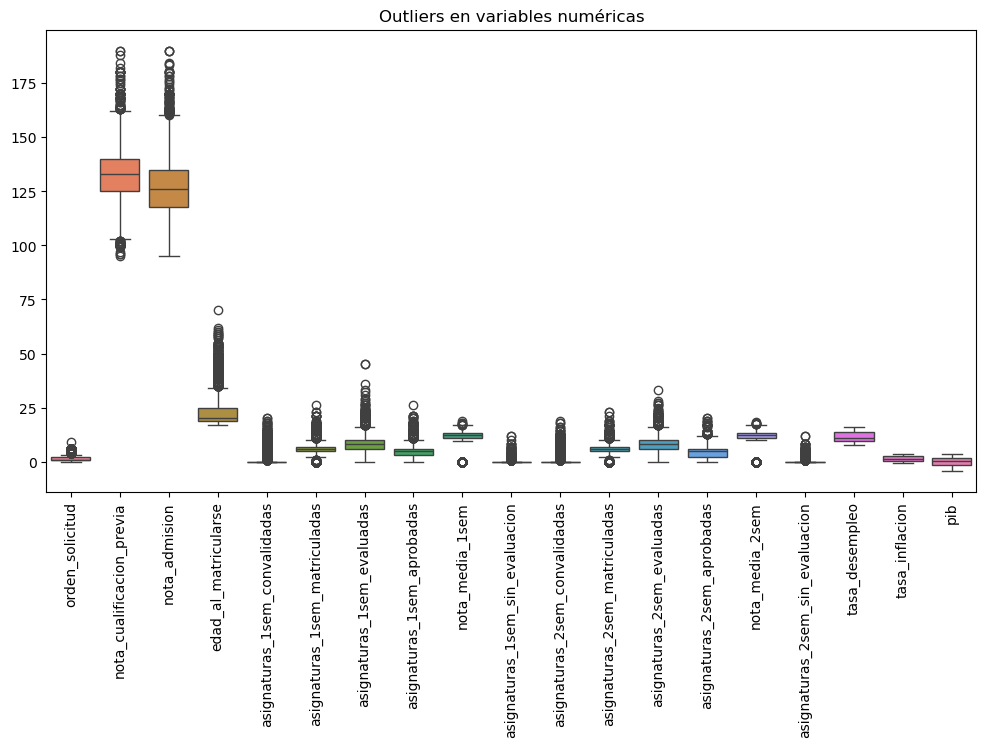

In [8]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=90)
plt.title("Outliers en variables numéricas")
plt.show()

Para la detección de valores atípicos empleamos el criterio del rango intercuartílico (IQR), calculando el porcentaje de outliers en cada variable. Observamos que algunas variables, como las notas medias o el número de asignaturas convalidadas, presentan un porcentaje relativamente elevado de valores extremos.

No obstante, no los eliminaremos, ya que no representan errores de medición sino comportamientos reales dentro del conjunto de datos (por ejemplo, estudiantes con bajo rendimiento o trayectorias académicas atípicas). Su eliminación podría introducir sesgos en el modelo y reducir su capacidad de generalización

OUTLIERS: VARIABLES CATEGÓRICAS

In [9]:
cat_summary = pd.DataFrame({
    'n_unique': df[cat_cols].nunique(),
    'top': df[cat_cols].mode().iloc[0],
    'freq_top': [df[col].value_counts(normalize=True).iloc[0] for col in cat_cols]
})

print(cat_summary)

                                   n_unique  \
estado_civil                              6   
modo_solicitud                           18   
curso                                    17   
asistencia_diurna_vespertina              2   
cualificacion_previa                     17   
nacionalidad                             21   
cualificacion_madre                      29   
cualificacion_padre                      34   
ocupacion_madre                          32   
ocupacion_padre                          46   
desplazado                                2   
necesidades_educativas_especiales         2   
deudor                                    2   
matricula_al_dia                          2   
genero                                    2   
becado                                    2   
internacional                             2   

                                                                          top  \
estado_civil                                                        solt

Para las variables categóricas, realizamos un análisis del número de categorías y de la frecuencia de la categoría más común. Observamos que algunas variables presentan un alto número de categorías (como la ocupación o la cualificación de los progenitores), lo que puede incrementar la dimensionalidad tras la codificación. Asimismo, ciertas variables muestran una distribución muy desbalanceada, con una categoría claramente dominante.

No obstante, mantenemos todas las variables y aplicamos codificación One-Hot, ya que estas características pueden seguir aportando información relevante al modelo, y su tratamiento mediante pipelines permite gestionar adecuadamente su impacto.

DIVISIÓN DE TRAIN/ VALIDACIÓN/ TEST

Dividimos el conjunto de datos en tres subconjuntos: entrenamiento (60%), validación (20%) y test (20%). Se utiliza partición estratificada para preservar la distribución de clases en cada subconjunto.

El conjunto de test queda completamente aislado hasta la evaluación final, para garantizar una estimación realista del rendimiento en datos no vistos.

In [ ]:
#Primera división: separamos test del resto
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#Segunda división: separamos train y validación
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
    # 0.25 × 0.80 = 0.20 del total → validación = 20%
)

print(f"Train:      {X_train.shape[0]} muestras")
print(f"Validación: {X_val.shape[0]} muestras")
print(f"Test:       {X_test.shape[0]} muestras")

Pipeline de preprocesado

Se construye un ColumnTransformer con dos ramas:
- Variables numéricas → StandardScaler (estandarización a media 0 y desviación típica 1)
- Variables categóricas → OneHotEncoder con `handle_unknown='ignore'`

El pipeline se **ajusta únicamente con el conjunto de entrenamiento** (`fit`) y se aplica al resto mediante `transform`, evitando así la fuga de información (*data leakage*).

In [ ]:
#definición del preprocesador
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

#ajuste SOLO sobre train → transform sobre val y test
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)

print(f"Dimensiones tras preprocesado:")
print(f"  X_train: {X_train_proc.shape}")
print(f"  X_val:   {X_val_proc.shape}")
print(f"  X_test:  {X_test_proc.shape}")